In [99]:
!pip install fastai
import numpy as np
import pandas as pd 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 50.8 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

Reading the data

In [69]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

As we can observe that the features Age and Cabin has very high number of null values, so we must fill the null values of these features appropriately.

Extracting the mode of each features

In [71]:
modes = df.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

Filling the null values with the highest frequently occuring value for each features

In [72]:
df.fillna(modes,inplace=True)

In [73]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [74]:
df = df.rename(columns={i:i.lower() for i in df.columns})
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S


Studying the data

In [75]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

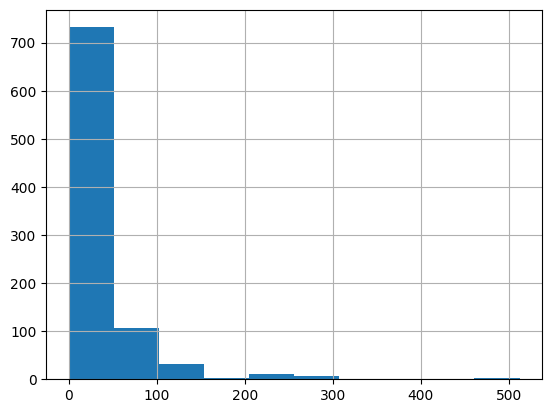

In [76]:
df['fare'].hist()

As we can observe from the above diagram that, the feature fare is right-tailed, which can bring inconsistency while training the model because the large outliers might dominate the small values. so we must apply the logarithm to the fare feature, which makes the data distribution symmetric that helps in the converging the cost function.

In [77]:
df['fare'] = np.log(df['fare'] + 1)  #here we are adding +1 inorder to avoid the infinity value
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,B96 B98,S


In [78]:
def classify(df):
    target = 'survived'
    numerical = [c for c in df.select_dtypes(include=np.number).columns if c!=target]
    categorical = [c for c in df.select_dtypes(exclude=np.number).columns if c!=target]
    continuous = [feature for feature in numerical if df[feature].nunique()>20]
    discrete = [feature for feature in numerical if df[feature].nunique()<=20]
    return numerical, categorical, continuous, discrete
numerical, categorical, continuous, discrete = classify(df)


In [79]:
print('The numerical features are:', numerical)
print('The categorical features are:', categorical)
print()

The numerical features are: ['passengerid', 'pclass', 'age', 'sibsp', 'parch', 'fare']
The categorical features are: ['name', 'sex', 'ticket', 'cabin', 'embarked']



One-hot encoding for the necessary features

In [80]:
df = pd.get_dummies(df,columns=['sex','pclass','embarked'],dtype = int)

Dropping the unnecessary columns

In [81]:
df.head()

,passengerid,survived,name,age,sibsp,parch,ticket,fare,cabin,sex_female,sex_male,pclass_1,pclass_2,pclass_3,embarked_C,embarked_Q,embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,2.110213,B96 B98,0,1,0,0,1,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,4.280593,C85,1,0,1,0,0,1,0,0
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,2.188856,B96 B98,1,0,0,0,1,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,3.990834,C123,1,0,1,0,0,0,0,1
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,2.202765,B96 B98,0,1,0,0,1,0,0,1


In [82]:
indep_features = [feature for feature in df.columns if feature not in ['passengerid','survived','name','ticket','cabin']]

Converting both the training features and the target feature into pytorch tensor objects

In [83]:
import torch
from torch import tensor
t_dependent = tensor(df['survived'],dtype = torch.float)
t_independent = tensor(df[indep_features].values, dtype = torch.float)


In [84]:
torch.manual_seed(442)
num_coeffs = t_independent.shape[1]  #required number of coefficients for each features
coeffs = (torch.rand(num_coeffs)-0.5).requires_grad_(True)  #here we are assigning the initial weights of each feature between the range of -0.5 and 0.5
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,
         0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)

Multiplication of initial weights of the features with the features itself

In [85]:
coeffs * t_independent

tensor([[-10.1838,   0.1386,   0.0000,  ...,  -0.0000,   0.0000,   0.3625],
        [-17.5902,   0.1386,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.0000,   0.0000,   0.3625],
        ...,
        [-11.1096,   0.1386,   0.4818,  ...,  -0.0000,   0.0000,   0.3625],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-14.8128,   0.0000,   0.0000,  ...,  -0.0000,   0.2103,   0.0000]],
       grad_fn=<MulBackward0>)

As we can observe from the above result that, the value of age is dominating the other values, due to the wide range of value in feature age. So we need to do some scaling.

Finding the maximum value based on each feature

In [86]:
vals , indices = t_independent.max(dim = 0) 

Scaling of the independent features

In [87]:
t_independent = t_independent / vals
t_independent

tensor([[0.2750, 0.1250, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
        [0.4750, 0.1250, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.3250, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
        ...,
        [0.3000, 0.1250, 0.3333,  ..., 0.0000, 0.0000, 1.0000],
        [0.3250, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.4000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.0000]])

In [88]:
coeffs * t_independent

tensor([[-0.1273,  0.0173,  0.0000,  ..., -0.0000,  0.0000,  0.3625],
        [-0.2199,  0.0173,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.3625],
        ...,
        [-0.1389,  0.0173,  0.0803,  ..., -0.0000,  0.0000,  0.3625],
        [-0.1504,  0.0000,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1852,  0.0000,  0.0000,  ..., -0.0000,  0.2103,  0.0000]],
       grad_fn=<MulBackward0>)

Now we can see that, not any particular multiplication value is dominating others.

Making a prediction using very first initial coefficients

In [89]:
predictions = (coeffs * t_independent).sum(axis = 1)
print('The first five predictions are:', predictions[:5])

The first five predictions are: tensor([ 0.1412, -0.5725,  0.1494,  0.2571,  0.0453], grad_fn=<SliceBackward0>)


Calculation of loss

In [90]:
loss = torch.abs(predictions - t_dependent).mean()
loss

tensor(0.5200, grad_fn=<MeanBackward0>)

Function to calculate the prediction done by model

In [91]:
def calculate_prediction(coeffs , t_independent):
    return (coeffs * t_independent).sum(axis = 1)

Function to calculate the loss

In [92]:
def calculate_loss(coeffs,t_dependent,t_independent):
    return torch.abs(calculate_prediction(coeffs , t_independent) - t_dependent).mean()
    

In [93]:
loss = calculate_loss(coeffs, t_dependent,t_independent)
loss.backward()
coeffs.grad

tensor([-0.0483,  0.0118, -0.0041, -0.0804, -0.1975,  0.1111, -0.1235, -0.0426,
         0.0797, -0.1886, -0.0617,  0.1639])

One Gradient descent step

In [95]:
loss = calculate_loss(coeffs,t_dependent,t_independent)
loss.backward()  #calculating the gradient using the loss and the coefficient
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 0.1)  #subtracting the gradient with the learning rate of 0.1
    coeffs.grad.zero_()    #removing the stored gradient value or setting the gradient value to 0
    print(calculate_loss(coeffs,t_dependent,t_independent))
    


tensor(0.4804)


In [101]:
from fastai.data.transforms import RandomSplitter
trn_split,val_split = RandomSplitter(seed = 42)(df)

In [102]:
trn_independent,val_independent = t_independent[trn_split], t_independent[val_split]
trn_dependent,val_dependent = t_dependent[trn_split], t_dependent[val_split]

Function to initialise the inital weights of the features

In [96]:
def init_coeffs():
    torch.manual_seed(442)
    num_coeffs = t_independent.shape[1]  #required number of coefficients for each features
    coeffs = (torch.rand(num_coeffs)-0.5).requires_grad_(True)  #here we are assigning the initial weights of each feature between the range of -0.5 and 0.5
    return coeffs 

Function to update the weights of the training features

In [105]:
def update_coeffs(coeffs,lr):
    coeffs.sub_(coeffs.grad * lr)  #subtracting with the learning rate
    coeffs.grad.zero_()
    
    

Function to calculate loss in one epoch


In [106]:
def calculate_epoch(coeffs,lr):
    loss = calculate_loss(coeffs,t_dependent,t_independent)
    loss.backward()  #calculating the gradient using the loss and the coefficient
    with torch.no_grad():
        update_coeffs(coeffs,lr)
    print('loss value is:', loss)

Training the model

In [109]:
def train_model(epochs,lr):
    coeffs = init_coeffs()
    for i in range(epochs):
        calculate_epoch(coeffs,lr)
    return coeffs    
final_coeffs = train_model(30,0.1)
print('The final weight for each features is:', final_coeffs)

loss value is: tensor(0.5200, grad_fn=<MeanBackward0>)
loss value is: tensor(0.5056, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4926, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4806, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4688, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4570, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4452, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4336, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4220, grad_fn=<MeanBackward0>)
loss value is: tensor(0.4109, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3998, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3889, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3783, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3678, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3576, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3481, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3398, grad_fn=<MeanBackward0>)
loss value is: tensor(0.3325, grad_fn=<MeanBackward0>)
loss value

As we can observe from the above result that the loss is decreasing.

In [111]:
def show_coeffs():
    return dict(zip(indep_features,final_coeffs.requires_grad_(False)))
print('The final coefficients for each features are:', show_coeffs())   

The final coefficients for each features are: {'age': tensor(-0.2752), 'sibsp': tensor(0.0967), 'parch': tensor(0.2384), 'fare': tensor(0.0012), 'sex_female': tensor(0.2140), 'sex_male': tensor(-0.4265), 'pclass_1': tensor(0.7163), 'pclass_2': tensor(0.4069), 'pclass_3': tensor(0.3232), 'embarked_C': tensor(0.0280), 'embarked_Q': tensor(0.2478), 'embarked_S': tensor(0.2233)}


Prediction done on cross_validation dataset

In [120]:
eval_prediction = (final_coeffs * val_independent).sum(axis = 1)
print('The prediction done on first five cross_validation dataset is:', eval_prediction[:5])

The prediction done on first five cross_validation dataset is: tensor([ 0.7866,  0.0623, -0.1575,  0.1427,  0.1183])
